<a href="https://colab.research.google.com/github/harmanbajwa2954/Machine-Learning-Notebooks/blob/main/Linear_Regression_realEstate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression on Real Estate Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# loading dataset

data = pd.read_csv('https://raw.githubusercontent.com/harmanbajwa2954/datasets/refs/heads/main/Real%20estate.csv')
data

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


## Exploratory Data Analysis (EDA)

In [ ]:
data.drop('No',inplace=True, axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [ ]:
#checking for number of null values in each column
data.isnull().sum()

,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


### Visualization

**Corelation Heatmap**

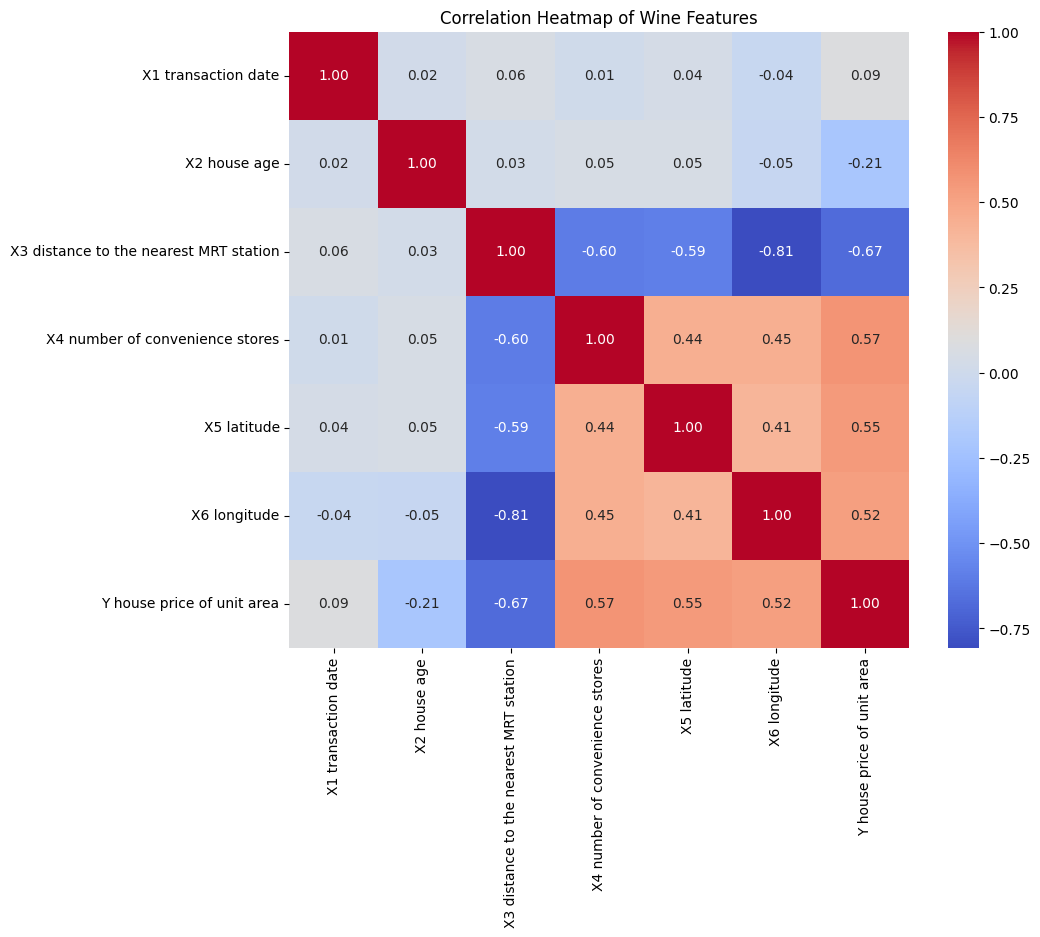

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Wine Features')
plt.show()

***Checking for Distribution of Target Variable — House Price of Unit Area***

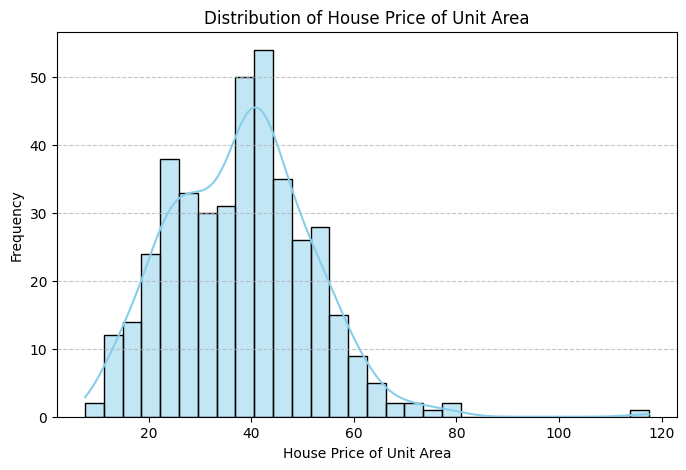

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(x='Y house price of unit area', data=data, kde=True, bins=30, color='skyblue')
plt.title('Distribution of House Price of Unit Area')
plt.xlabel('House Price of Unit Area')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Linear Regresion Modeling


### Test-Train Split

In [ ]:
X = data.drop('Y house price of unit area', axis=1)
y = data['Y house price of unit area']

#spliting between 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Initializationa and fitting

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#making Predicition
y_pred = model.predict(X_test)

### Model Evaluation

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")


--- Model Evaluation ---
Mean Squared Error (MSE): 53.5056
R-squared (R2): 0.6811


## Visualizing Actual vs Predicted

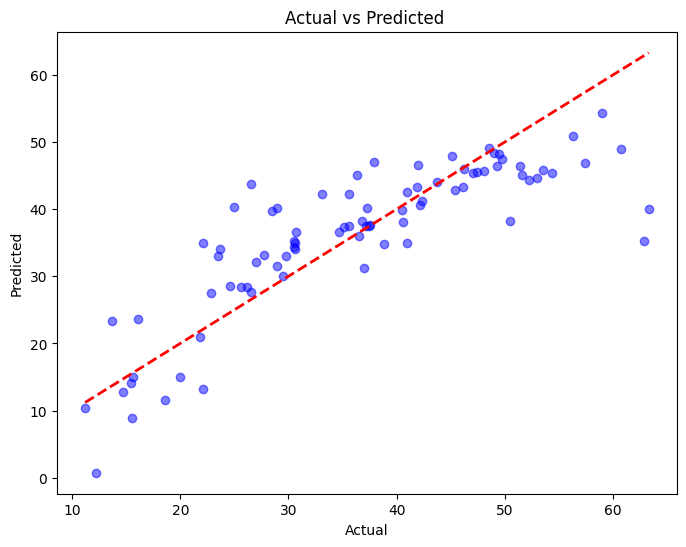

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
# Plotting the ideal perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted ')
plt.show()

### Testing on User Data

In [ ]:
sample_data = pd.DataFrame({
    'X1 transaction date': [2013.0, 2013.25, 2012.917],
    'X2 house age': [10.0, 5.0, 20.0],
    'X3 distance to the nearest MRT station': [1000.0, 50.0, 800.0],
    'X4 number of convenience stores': [5, 10, 3],
    'X5 latitude': [24.97, 24.98, 24.96],
    'X6 longitude': [121.53, 121.54, 121.52]
})

print("Sample Data:")
print(sample_data)

sample_predictions = model.predict(sample_data)

print("\nPredicted House Prices for Sample Data:")
for i, price in enumerate(sample_predictions):
    print(f"Sample {i+1}: {price:.2f}")

Sample Data:
   X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2013.000          10.0                                  1000.0   
1             2013.250           5.0                                    50.0   
2             2012.917          20.0                                   800.0   

   X4 number of convenience stores  X5 latitude  X6 longitude  
0                                5        24.97        121.53  
1                               10        24.98        121.54  
2                                3        24.96        121.52  

Predicted House Prices for Sample Data:
Sample 1: 40.94
Sample 2: 55.63
Sample 3: 34.56


## Saving the model as a Pickle File 🥒

In [ ]:
import pickle as pkl

model_data = {"model":model,"features":X.columns.tolist()}
with open("real_estate_model.pkl","wb") as file:
  pkl.dump(model_data,file)